In [1]:

path = '/home/apolo/Documents/github_projects/ripple_sync/'

scripts_path = path + '/scripts/'
tables_path = path + '/tables/'
figures_path = path + '/figures/'


In [2]:

import pandas as pd
import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns 
import dabest

import math
import scipy.signal as sig
from scipy import stats as stats

from statsmodels.stats.proportion import proportions_chisquare
import statsmodels.api as sm
import statsmodels.formula.api as smf

%matplotlib widget

import helper_functions as hf

import statsmodels.api as sm
import statsmodels.formula.api as smf


In [3]:
path = '/home/apolo/Documents/github_projects/pcx-1/'

import os

%matplotlib widget
os.chdir(path + '/scripts/')

from pcx1_helper_functions import helper_functions as pcx1_hf, loading_functions as lf, \
    surrogate_functions as surrogate, decoding_model_helper_functions as decode, \
    detect_peaks as dp, wavelet_base_functions as wf, list_manipulation_functions as lmf, \
    waveform_classifier as wave_class, EMDlib as emd, normalization_functions as nf


In [4]:

import warnings

warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

# set the font globally
plt.rcParams.update({'font.family':'sans-serif'})
# set the font name for a font family
plt.rcParams.update({'font.sans-serif':'Arial'})
# when saving svg, keep text as text
plt.rcParams['svg.fonttype'] = 'none' 


In [5]:
sampling_rate = 1250.


In [6]:
os.chdir(tables_path + '/figure_7/')

filename = 'Figure_Ripple_Spike_Phase_Distribution'
spiking_dict = np.load(filename,allow_pickle=True).item()


In [7]:

nbins = 60
bin_edges = np.linspace(-np.pi,np.pi,nbins+1)
bin_center = bin_edges[0:-1] + np.diff(bin_edges)/2
two_cycles_bin_center = np.concatenate([bin_center, bin_center + 2*np.pi])
bin_dt = 0.9*np.diff(bin_edges)[0]


In [9]:
spiking_dict.keys()

dict_keys(['rat', 'session', 'shank_side', 'shank_distance', 'neuron_shank', 'neuron_ID', 'neuron_type', 'neuron_to_ripple_side', 'ripple_shank', 'mean_phase_ripple_epochs', 'spike_phase_distribution', 'ripple_phase_distribution'])

(559,)
(559, 60)


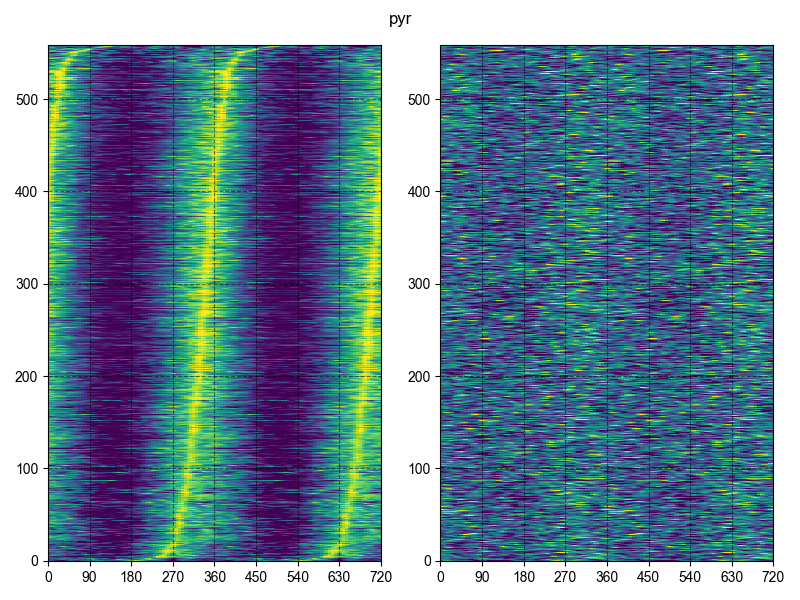

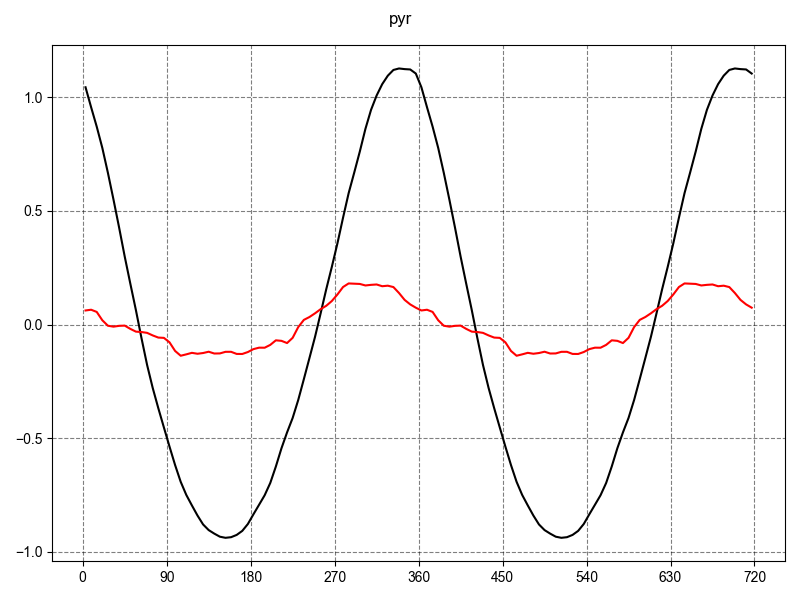

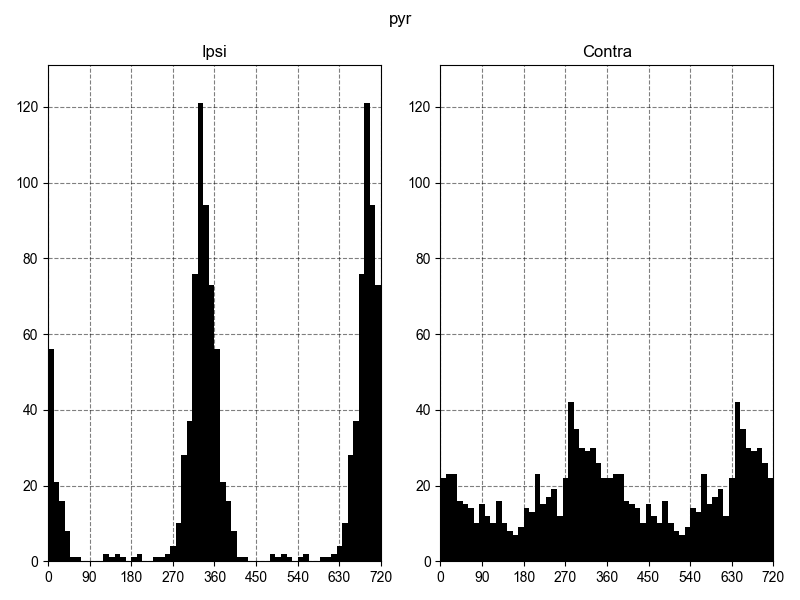

(128,)
(128, 60)


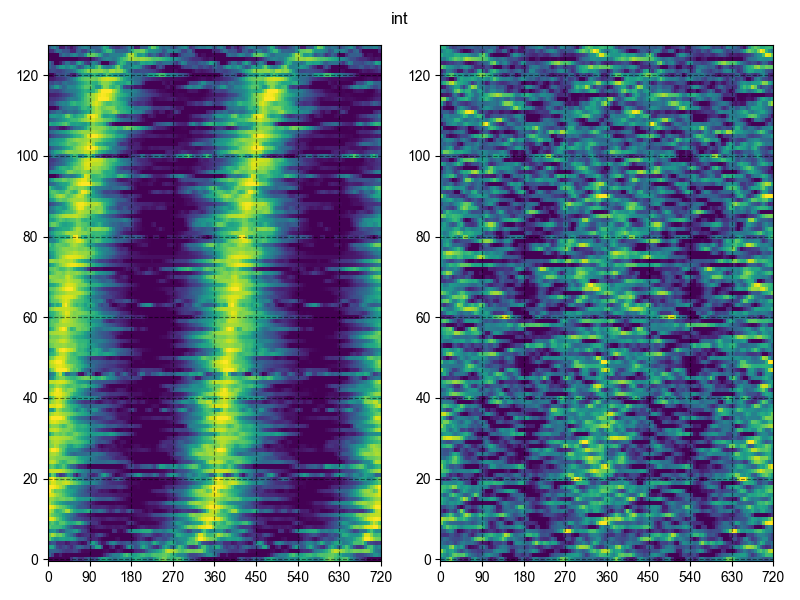

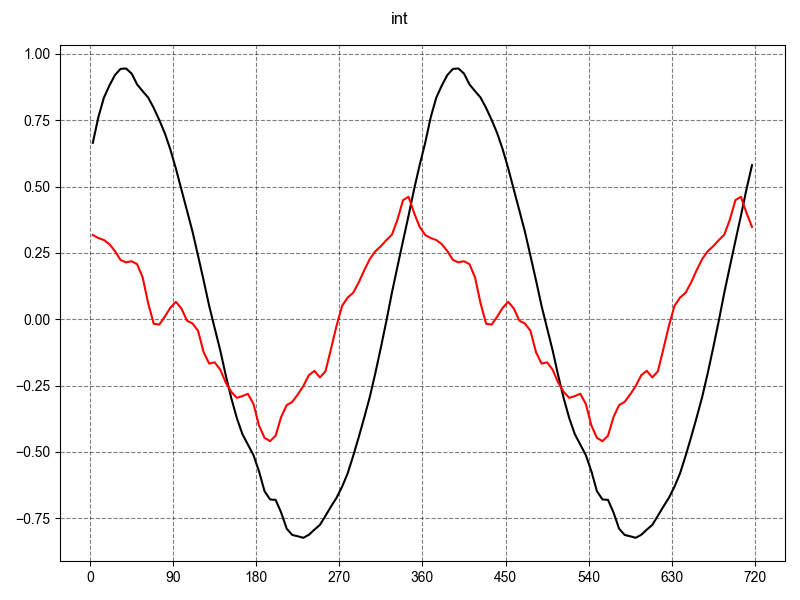

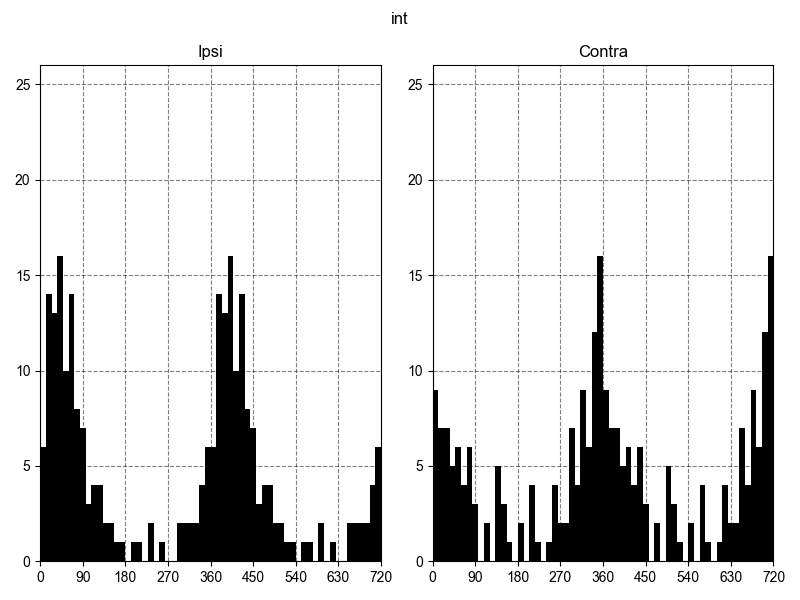

In [8]:

neuron_types = ['pyr','int']

for neuron_type in neuron_types:
    
    neuron_type_sliced = lmf.find_single_string_in_list(spiking_dict['neuron_type'],neuron_type)
    
    neuron_ids_sliced = []
    for idx in neuron_type_sliced:
        neuron_ids_sliced.append(spiking_dict['neuron_ID'][idx])
    neuron_ids_sliced = np.unique(neuron_ids_sliced)
    
    pooled_spike_phase_distribution_ipsi = []
    pooled_spike_phase_distribution_contra = []
    
    pooled_mean_phase_distribution_ipsi = []
    pooled_mean_phase_distribution_contra = []
    
    for neuron_id in neuron_ids_sliced:
    
        neuron_id_idx = np.array(lmf.find_single_string_in_list(spiking_dict['neuron_ID'], neuron_id))

        neuron_id_idx_contra = neuron_id_idx[np.array(lmf.select(spiking_dict['neuron_to_ripple_side'],neuron_id_idx)) == 'contra']
        spike_phase_distribution_contra_aux = []
        mean_phase_distribution_contra_aux = []
        for idx in neuron_id_idx_contra:
        
            spike_phase_distribution = spiking_dict['spike_phase_distribution'][idx].copy()
            mean_phase = spiking_dict['mean_phase_ripple_epochs'][idx].copy()
            ripple_phase_distribution = spiking_dict['ripple_phase_distribution'][idx].copy()
            spike_phase_distribution = spike_phase_distribution/(ripple_phase_distribution/sampling_rate)
            
            spike_phase_distribution_contra_aux.append(spike_phase_distribution)
            mean_phase_distribution_contra_aux.append(mean_phase)
    
        spike_phase_distribution_contra_aux = np.array(spike_phase_distribution_contra_aux)
        mean_phase_distribution_contra_aux = np.array(mean_phase_distribution_contra_aux)

        mean_spike_phase_distribution_contra = np.nanmean(spike_phase_distribution_contra_aux,0)
        mean_phase_distribution_contra = stats.circmean(mean_phase_distribution_contra_aux, low=-math.pi, high=math.pi)
        
        pooled_spike_phase_distribution_contra.append(mean_spike_phase_distribution_contra)
        pooled_mean_phase_distribution_contra.append(mean_phase_distribution_contra)


        neuron_id_idx_ipsi = neuron_id_idx[np.array(lmf.select(spiking_dict['neuron_to_ripple_side'],neuron_id_idx)) == 'ipsi']
        spike_phase_distribution_ipsi_aux = []
        mean_phase_distribution_ipsi_aux = []
        for idx in neuron_id_idx_ipsi:
    
            spike_phase_distribution = spiking_dict['spike_phase_distribution'][idx].copy()
            mean_phase = spiking_dict['mean_phase_ripple_epochs'][idx].copy()
            ripple_phase_distribution = spiking_dict['ripple_phase_distribution'][idx].copy()
            spike_phase_distribution = spike_phase_distribution/(ripple_phase_distribution/sampling_rate)
            
            spike_phase_distribution_ipsi_aux.append(spike_phase_distribution)
            mean_phase_distribution_ipsi_aux.append(mean_phase)
    
        spike_phase_distribution_ipsi_aux = np.array(spike_phase_distribution_ipsi_aux)
        mean_phase_distribution_ipsi_aux = np.array(mean_phase_distribution_ipsi_aux)

        mean_spike_phase_distribution_ipsi = np.nanmean(spike_phase_distribution_ipsi_aux,0)
        mean_phase_distribution_ipsi = stats.circmean(mean_phase_distribution_ipsi_aux, low=-math.pi, high=math.pi)
        
        pooled_spike_phase_distribution_ipsi.append(mean_spike_phase_distribution_ipsi)
        pooled_mean_phase_distribution_ipsi.append(mean_phase_distribution_ipsi)
        
    
    pooled_spike_phase_distribution_ipsi = np.array(pooled_spike_phase_distribution_ipsi)
    pooled_mean_phase_distribution_ipsi = np.array(pooled_mean_phase_distribution_ipsi)

    pooled_spike_phase_distribution_contra = np.array(pooled_spike_phase_distribution_contra)
    pooled_mean_phase_distribution_contra = np.array(pooled_mean_phase_distribution_contra)

    pooled_spike_phase_distribution_ipsi = nf.z_score_norm(pooled_spike_phase_distribution_ipsi,1)
    # pooled_spike_phase_distribution_ipsi = nf.min_max_norm(pooled_spike_phase_distribution_ipsi,1)
    concat_ipsi = np.concatenate([pooled_spike_phase_distribution_ipsi,pooled_spike_phase_distribution_ipsi,pooled_spike_phase_distribution_ipsi,pooled_spike_phase_distribution_ipsi],1)
    smoothed_ipsi = pcx1_hf.gaussian_smooth_1d(concat_ipsi,1)
    two_cycles_phase_ipsi = smoothed_ipsi[:,nbins:3*nbins]
    # two_cycles_phase_ipsi = nf.z_score_norm(two_cycles_phase_ipsi,1)

    pooled_spike_phase_distribution_contra = nf.z_score_norm(pooled_spike_phase_distribution_contra,1)
    # pooled_spike_phase_distribution_contra = nf.min_max_norm(pooled_spike_phase_distribution_contra,1)
    concat_contra = np.concatenate([pooled_spike_phase_distribution_contra,pooled_spike_phase_distribution_contra,pooled_spike_phase_distribution_contra,pooled_spike_phase_distribution_contra],1)
    smoothed_contra = pcx1_hf.gaussian_smooth_1d(concat_contra,1)
    two_cycles_phase_contra = smoothed_contra[:,nbins:3*nbins]
    # two_cycles_phase_contra = nf.z_score_norm(two_cycles_phase_contra,1)
    
    print(pooled_mean_phase_distribution_ipsi.shape)
    print(pooled_spike_phase_distribution_contra.shape)
    
    i_sorted = np.argmax(two_cycles_phase_ipsi,1)
    sorted_indices,sorted_phase_values = pcx1_hf.circular_sort(two_cycles_bin_center[i_sorted])

    phase_xticks = np.linspace(0,4*math.pi,9)
    phase_labels =  ['0', '$\pi/2$', '$\pi$', '$3\pi/2$', '$2\pi$', '$5\pi/2$', '$3\pi$', '$7\pi/2$', '$4\pi$']
    phase_xticks = np.linspace(0,720,9)


    plt.figure(figsize=(8,6))
    
    plt.subplot(1,2,1)
    plt.pcolormesh(np.rad2deg(two_cycles_bin_center + math.pi),np.arange(two_cycles_phase_ipsi.shape[0]),two_cycles_phase_ipsi[sorted_indices,:],shading='auto',rasterized=True)
    # plt.colorbar()
    plt.clim([-1,2])
    plt.xticks(phase_xticks)
    plt.grid(color='black',ls='--',alpha=0.5)
    
    plt.subplot(1,2,2)
    plt.pcolormesh(np.rad2deg(two_cycles_bin_center + math.pi),np.arange(two_cycles_phase_contra.shape[0]),two_cycles_phase_contra[sorted_indices,:],shading='auto',rasterized=True)
    # plt.colorbar()
    plt.clim([-1,2])
    plt.xticks(phase_xticks)
    plt.grid(color='black',ls='--',alpha=0.5)
    plt.suptitle(neuron_type)
    plt.tight_layout()

    
    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_spike_phase_distribution.svg'
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # hf.delete_clip_path(fig_name)
    



    
    
    plt.figure(figsize=(8,6))
    plt.plot(np.rad2deg(two_cycles_bin_center + math.pi),np.nanmean(two_cycles_phase_ipsi,0),'k')
    plt.plot(np.rad2deg(two_cycles_bin_center + math.pi),np.nanmean(two_cycles_phase_contra,0),'r')
    # plt.ylim([-1,1])
    plt.suptitle(neuron_type)
    plt.xticks(phase_xticks)
    plt.grid(color='black',ls='--',alpha=0.5)
    plt.tight_layout()

    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_mean_spike_phase_distribution.svg'
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # hf.delete_clip_path(fig_name)
    
    
    
    nbins_hist = 30
    bin_edges_hist = np.linspace(-np.pi,np.pi,nbins_hist+1)
    bin_center_hist = bin_edges_hist[0:-1] + np.diff(bin_edges_hist)/2
    two_cycles_bin_center_hist = np.concatenate([bin_center_hist, bin_center_hist + 2*np.pi])
    bin_dt_hist = 0.9*np.diff(bin_edges_hist)[0]
    
    counts_ipsi, _ = np.histogram(pooled_mean_phase_distribution_ipsi,bin_edges_hist)
    counts_contra, _ = np.histogram(pooled_mean_phase_distribution_contra,bin_edges_hist)
    

    plt.figure(figsize=(8,6))
    plt.subplot(1,2,1)
    plt.bar(np.rad2deg(two_cycles_bin_center_hist + math.pi),np.concatenate([counts_ipsi,counts_ipsi],0),width=12,color='black')
    plt.ylim([0,np.max([counts_ipsi,counts_contra])+10])
    plt.xticks(phase_xticks)
    plt.grid(color='black',ls='--',alpha=0.5)
    plt.xlim([0,720])
    plt.title('Ipsi')
    
    plt.subplot(1,2,2)
    plt.bar(np.rad2deg(two_cycles_bin_center_hist + math.pi),np.concatenate([counts_contra,counts_contra],0),width=12,color='black')
    plt.ylim([0,np.max([counts_ipsi,counts_contra])+10])
    plt.xticks(phase_xticks)
    plt.grid(color='black',ls='--',alpha=0.5)
    plt.xlim([0,720])
    plt.title('Contra')
    plt.suptitle(neuron_type)
    plt.tight_layout()
   
    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_histogram_mean_spike_phase_distribution.svg'
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # hf.delete_clip_path(fig_name)



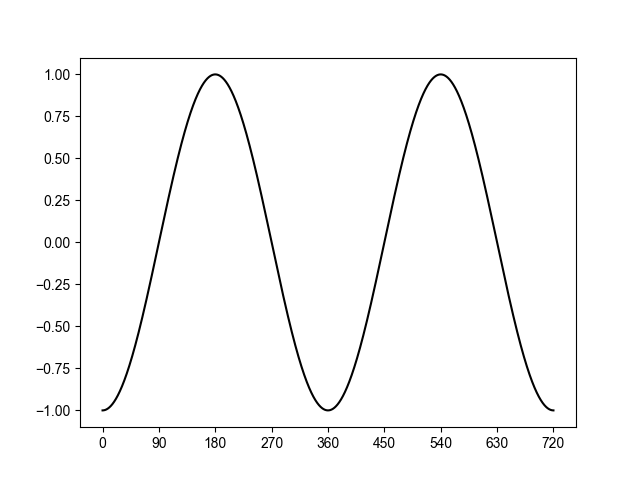

ClipPath elements deleted.
File saved.


In [11]:
srate = 1000
dt = 1/srate
phase_vec = np.arange(-math.pi,3*math.pi+dt,dt)
phase_vec_deg = np.rad2deg(phase_vec + math.pi)

signal = np.cos(phase_vec)
signal2 = np.sin(phase_vec)

plt.figure()
plt.plot(phase_vec_deg,signal,'k')
# plt.plot(phase_vec,signal2,'r')
plt.xticks(phase_xticks)

os.chdir(figures_path + '/figure_7/')
fig_name ='sine_wave.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)


In [9]:

os.chdir(tables_path + '/figure_7/')
filename = 'Figure_Ripple_Triggered_Spikes'
spiking_dict = np.load(filename,allow_pickle=True).item()


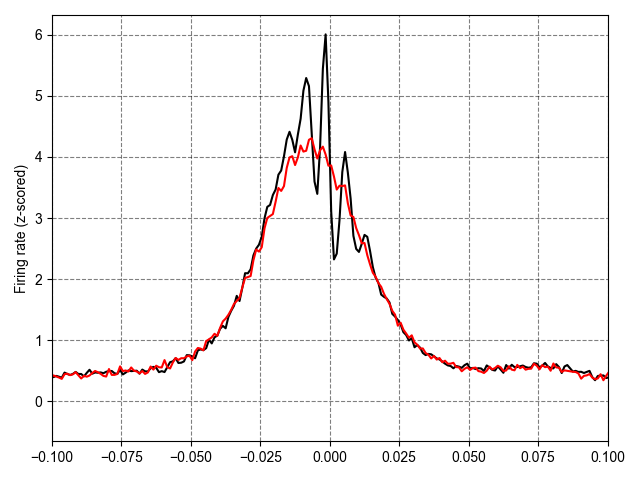

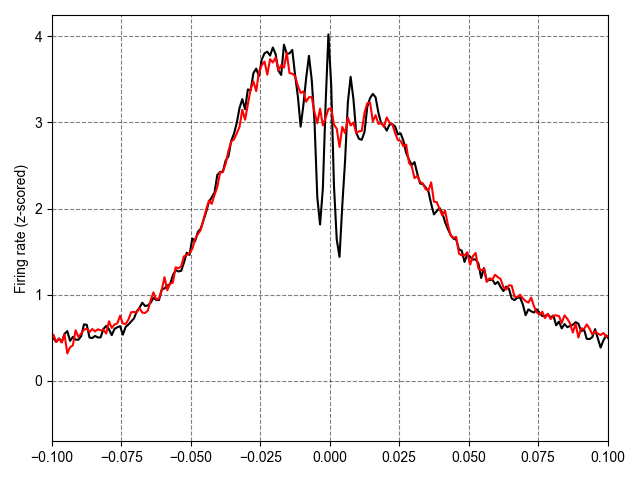

In [10]:

neuron_types = ['pyr','int']
# neuron_types = ['pyr']
for neuron_type in neuron_types:
    
    neuron_type_sliced = lmf.find_single_string_in_list(spiking_dict['neuron_type'],neuron_type)
    
    neuron_ids_sliced = []
    for idx in neuron_type_sliced:
        neuron_ids_sliced.append(spiking_dict['neuron_ID'][idx])
    neuron_ids_sliced = np.unique(neuron_ids_sliced)
    
    pooled_mean_ripple_triggered_spikes_ipsi = []
    pooled_mean_ripple_triggered_spikes_contra = []
        
    pooled_mean_ripple_counts_ipsi = []
    pooled_mean_ripple_counts_contra = []
    
    for neuron_id in neuron_ids_sliced:
    
        neuron_id_idx = np.array(lmf.find_single_string_in_list(spiking_dict['neuron_ID'], neuron_id))

        neuron_id_idx_contra = neuron_id_idx[np.array(lmf.select(spiking_dict['neuron_to_ripple_side'],neuron_id_idx)) == 'contra']
        ripple_triggered_spikes_contra_aux = []
        ripple_counts_contra_aux = []
        for idx in neuron_id_idx_contra:
    
            ripple_triggered_spikes = spiking_dict['ripple_triggered_spikes'][idx]
            ripple_counts = spiking_dict['ripple_counts'][idx]
            ripple_triggered_spikes_contra_aux.append(ripple_triggered_spikes)
            ripple_counts_contra_aux.append(ripple_counts)
            
    
        ripple_triggered_spikes_contra_aux = np.array(ripple_triggered_spikes_contra_aux)
        ripple_counts_contra_aux = np.array(ripple_counts_contra_aux)

        mean_ripple_triggered_spikes_contra = np.nanmean(ripple_triggered_spikes_contra_aux,0)
        mean_ripple_counts_contra = np.nanmean(ripple_counts_contra_aux,0)
        
        pooled_mean_ripple_triggered_spikes_contra.append(mean_ripple_triggered_spikes_contra)
        pooled_mean_ripple_counts_contra.append(mean_ripple_counts_contra)


        neuron_id_idx_ipsi = neuron_id_idx[np.array(lmf.select(spiking_dict['neuron_to_ripple_side'],neuron_id_idx)) == 'ipsi']
        ripple_triggered_spikes_ipsi_aux = []
        ripple_counts_ipsi_aux = []
        for idx in neuron_id_idx_ipsi:
    
            ripple_triggered_spikes = spiking_dict['ripple_triggered_spikes'][idx]
            ripple_counts = spiking_dict['ripple_counts'][idx]
            ripple_triggered_spikes_ipsi_aux.append(ripple_triggered_spikes)
            ripple_counts_ipsi_aux.append(ripple_counts)
            
    
        ripple_triggered_spikes_ipsi_aux = np.array(ripple_triggered_spikes_ipsi_aux)
        ripple_counts_ipsi_aux = np.array(ripple_counts_ipsi_aux)

        mean_ripple_triggered_spikes_ipsi = np.nanmean(ripple_triggered_spikes_ipsi_aux,0)
        mean_ripple_counts_ipsi = np.nanmean(ripple_counts_ipsi_aux,0)
        
        pooled_mean_ripple_triggered_spikes_ipsi.append(mean_ripple_triggered_spikes_ipsi)
        pooled_mean_ripple_counts_ipsi.append(mean_ripple_counts_ipsi)


    
    pooled_mean_ripple_triggered_spikes_contra = np.array(pooled_mean_ripple_triggered_spikes_contra)
    pooled_mean_ripple_counts_contra = np.array(pooled_mean_ripple_counts_contra)

    pooled_mean_ripple_triggered_spikes_ipsi = np.array(pooled_mean_ripple_triggered_spikes_ipsi)
    pooled_mean_ripple_counts_ipsi = np.array(pooled_mean_ripple_counts_ipsi)

       
    ripple_window = 1
    nbins = 2000
    bin_edges = np.linspace(-ripple_window,ripple_window,nbins+1)
    bin_center = bin_edges[0:-1] + np.diff(bin_edges)/2
    bin_dt = 1*np.diff(bin_edges)[0]
    
    plt.figure()
    plt.plot(bin_center,np.nanmean(nf.z_score_norm(pooled_mean_ripple_triggered_spikes_ipsi,1),0),'k')
    plt.plot(bin_center,np.nanmean(nf.z_score_norm(pooled_mean_ripple_triggered_spikes_contra,1),0),'r')
    plt.xlim([-0.1,0.1])
    plt.ylabel('Firing rate (z-scored)')
    plt.grid(color='black',ls='--',alpha=0.5)
    plt.tight_layout()

    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_ripple_triggered_spikes.svg'
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # hf.delete_clip_path(fig_name)


In [7]:
os.chdir(tables_path + '/figure_7/')

filename = 'Figure_Ripple_Spike_Triggered_Ripple'
spiking_dict = np.load(filename,allow_pickle=True).item()


In [8]:
srate = 1250
ripple_window = 1
plot_window = np.arange(-ripple_window*srate,+ripple_window*srate+1)/srate


In [62]:
spiking_dict.keys()

dict_keys(['rat', 'session', 'shank_side', 'shank_distance', 'neuron_shank', 'neuron_ID', 'neuron_type', 'neuron_to_ripple_side', 'ripple_shank', 'ripple_filtered_triggered', 'ripple_amp_triggered', 'ripple_counts'])

In [ ]:
from matplotlib.colors import TwoSlopeNorm


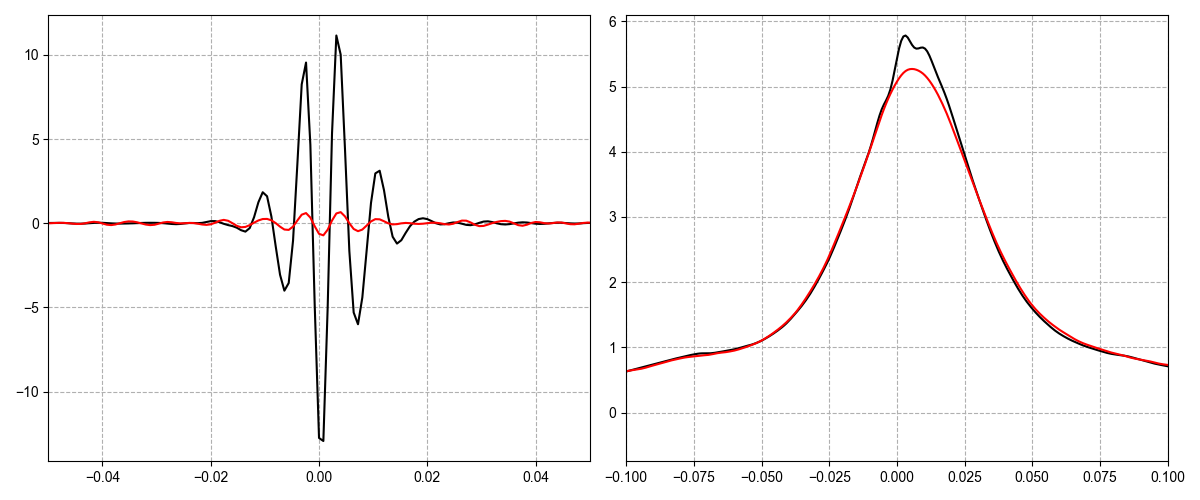

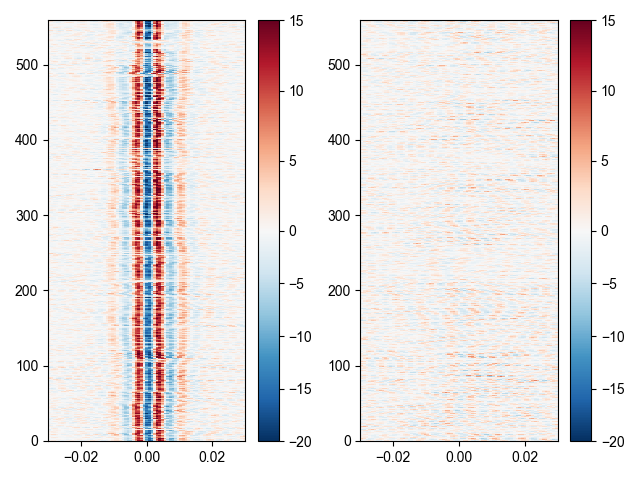

ClipPath elements deleted.
File saved.


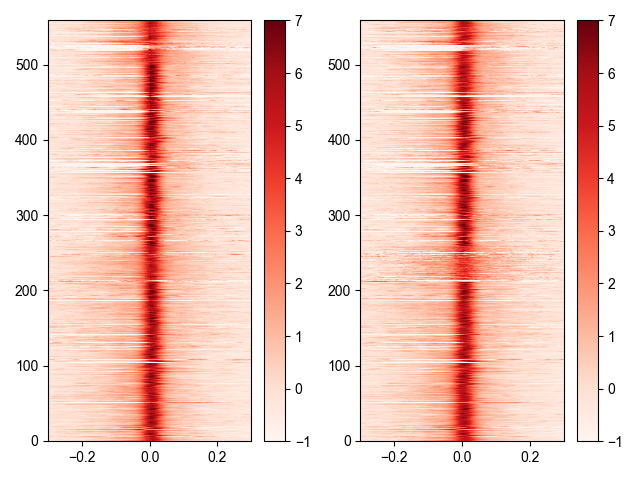

ClipPath elements deleted.
File saved.


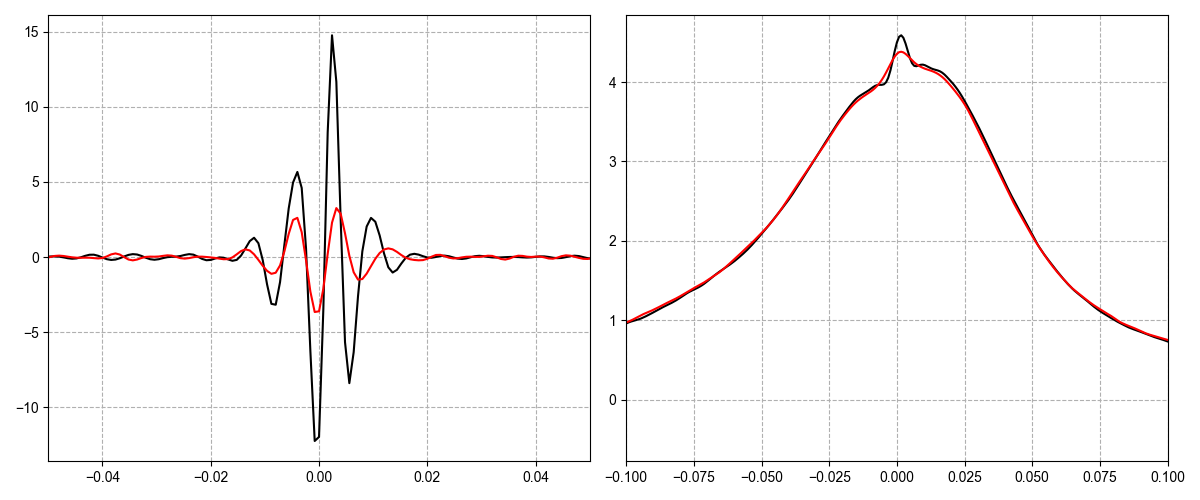

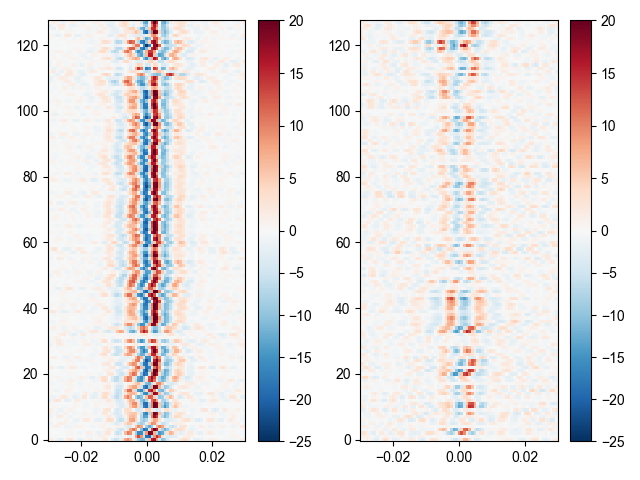

ClipPath elements deleted.
File saved.


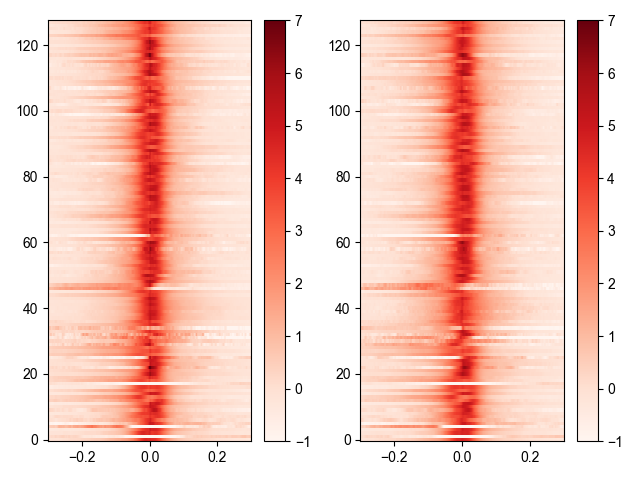

ClipPath elements deleted.
File saved.


In [32]:
plt.close('all')

neuron_types = ['pyr','int']
# neuron_types = ['pyr']
for neuron_type in neuron_types:
    
    neuron_type_sliced = lmf.find_single_string_in_list(spiking_dict['neuron_type'],neuron_type)
    
    neuron_ids_sliced = []
    for idx in neuron_type_sliced:
        neuron_ids_sliced.append(spiking_dict['neuron_ID'][idx])
    neuron_ids_sliced = np.unique(neuron_ids_sliced)
    
    pooled_mean_ripple_filtered_triggered_ipsi = []
    pooled_mean_ripple_filtered_triggered_contra = []
    
    pooled_mean_ripple_amp_triggered_ipsi = []
    pooled_mean_ripple_amp_triggered_contra = []
    
    for neuron_id in neuron_ids_sliced:
    
        neuron_id_idx = np.array(lmf.find_single_string_in_list(spiking_dict['neuron_ID'], neuron_id))

        neuron_id_idx_contra = neuron_id_idx[np.array(lmf.select(spiking_dict['neuron_to_ripple_side'],neuron_id_idx)) == 'contra']
        ripple_filtered_triggered_contra_aux = []
        ripple_amp_triggered_contra_aux = []
        for idx in neuron_id_idx_contra:
    
            ripple_filtered_triggered = spiking_dict['ripple_filtered_triggered'][idx]
            ripple_amp_triggered = spiking_dict['ripple_amp_triggered'][idx]
            
            ripple_filtered_triggered_contra_aux.append(ripple_filtered_triggered)
            ripple_amp_triggered_contra_aux.append(ripple_amp_triggered)
            
    
        ripple_filtered_triggered_contra_aux = np.array(ripple_filtered_triggered_contra_aux)
        ripple_amp_triggered_contra_aux = np.array(ripple_amp_triggered_contra_aux)

        mean_ripple_filtered_triggered_contra = np.nanmean(ripple_filtered_triggered_contra_aux,0)
        mean_ripple_amp_triggered_contra = np.nanmean(ripple_amp_triggered_contra_aux,0)
        
        pooled_mean_ripple_filtered_triggered_contra.append(mean_ripple_filtered_triggered_contra)
        pooled_mean_ripple_amp_triggered_contra.append(mean_ripple_amp_triggered_contra)


        neuron_id_idx_ipsi = neuron_id_idx[np.array(lmf.select(spiking_dict['neuron_to_ripple_side'],neuron_id_idx)) == 'ipsi']
        ripple_filtered_triggered_ipsi_aux = []
        ripple_amp_triggered_ipsi_aux = []
        for idx in neuron_id_idx_ipsi:
    
            ripple_filtered_triggered = spiking_dict['ripple_filtered_triggered'][idx]
            ripple_amp_triggered = spiking_dict['ripple_amp_triggered'][idx]
            
            ripple_filtered_triggered_ipsi_aux.append(ripple_filtered_triggered)
            ripple_amp_triggered_ipsi_aux.append(ripple_amp_triggered)
            
    
        ripple_filtered_triggered_ipsi_aux = np.array(ripple_filtered_triggered_ipsi_aux)
        ripple_amp_triggered_ipsi_aux = np.array(ripple_amp_triggered_ipsi_aux)

        mean_ripple_filtered_triggered_ipsi = np.nanmean(ripple_filtered_triggered_ipsi_aux,0)
        mean_ripple_amp_triggered_ipsi = np.nanmean(ripple_amp_triggered_ipsi_aux,0)
        
        pooled_mean_ripple_filtered_triggered_ipsi.append(mean_ripple_filtered_triggered_ipsi)
        pooled_mean_ripple_amp_triggered_ipsi.append(mean_ripple_amp_triggered_ipsi)


    pooled_mean_ripple_filtered_triggered_ipsi = np.array(pooled_mean_ripple_filtered_triggered_ipsi)
    pooled_mean_ripple_amp_triggered_ipsi = np.array(pooled_mean_ripple_amp_triggered_ipsi)

    pooled_mean_ripple_filtered_triggered_contra = np.array(pooled_mean_ripple_filtered_triggered_contra)
    pooled_mean_ripple_amp_triggered_contra = np.array(pooled_mean_ripple_amp_triggered_contra)

            
    pooled_ripple_filtered_triggered_ipsi_zscored = nf.z_score_norm(pooled_mean_ripple_filtered_triggered_ipsi, axis=1)
    pooled_ripple_filtered_triggered_contra_zscored = nf.z_score_norm(pooled_mean_ripple_filtered_triggered_contra, axis=1)

    pooled_ripple_amp_triggered_ipsi_zscored = nf.z_score_norm(pooled_mean_ripple_amp_triggered_ipsi, axis=1)
    pooled_ripple_amp_triggered_contra_zscored = nf.z_score_norm(pooled_mean_ripple_amp_triggered_contra, axis=1)


    
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(plot_window,np.nanmean(pooled_ripple_filtered_triggered_ipsi_zscored,0),'k')
    plt.plot(plot_window,np.nanmean(pooled_ripple_filtered_triggered_contra_zscored,0),'r')
    plt.xlim([-0.05,0.05])
    plt.grid(ls='--')
    
    plt.subplot(1,2,2)
    plt.plot(plot_window,np.nanmean(pooled_ripple_amp_triggered_ipsi_zscored,0),'k')
    plt.plot(plot_window,np.nanmean(pooled_ripple_amp_triggered_contra_zscored,0),'r')
    plt.xlim([-0.1,0.1])
    plt.grid(ls='--')
    plt.tight_layout()

    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_mean_spikes_triggered_ripple_amp_filtered.svg'
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # hf.delete_clip_path(fig_name)

    
    color_map = 'RdBu_r'
    # color_map = 'seismic'
    # ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu',
    # 'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic']
    
    i_sorted = np.argsort(np.argmax(pooled_ripple_filtered_triggered_ipsi_zscored,1))

    if neuron_type == 'int':
        norm = TwoSlopeNorm(vmin=-25, vcenter=0, vmax=20)
    else:
        norm = TwoSlopeNorm(vmin=-20, vcenter=0, vmax=15)
        
    plt.figure()
    plt.subplot(1,2,1)
    plt.pcolormesh(plot_window,np.arange(pooled_ripple_filtered_triggered_ipsi_zscored.shape[0]),
                   pooled_ripple_filtered_triggered_ipsi_zscored,shading='auto',cmap=color_map,norm=norm,rasterized=True)
    
        
    plt.colorbar()
    plt.xlim([-0.03,0.03])
    
    plt.subplot(1,2,2)
    plt.pcolormesh(plot_window,np.arange(pooled_ripple_filtered_triggered_contra_zscored.shape[0]),
                   pooled_ripple_filtered_triggered_contra_zscored,shading='auto',cmap=color_map,norm=norm,rasterized=True)

    
    plt.xlim([-0.03,0.03])
    plt.colorbar()
    
    plt.tight_layout()
    
    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_histogram_spikes_triggered_ripple_filtered.svg'
    plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    hf.delete_clip_path(fig_name)

    

    
    color_map = 'Reds'
    # ['viridis', 'plasma', 'inferno', 'magma', 'cividis']
    # ['Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
    # 'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
    # 'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn']
    
    i_sorted = np.argsort(np.argmax(pooled_ripple_filtered_triggered_ipsi_zscored,1))
    
    plt.figure()
    plt.subplot(1,2,1)
    plt.pcolormesh(plot_window,np.arange(pooled_ripple_amp_triggered_ipsi_zscored.shape[0]),
                   pooled_ripple_amp_triggered_ipsi_zscored,shading='auto',cmap=color_map,rasterized=True)
    plt.clim([-1,7])
    plt.colorbar()
    plt.xlim([-0.3,0.3])
    
    plt.subplot(1,2,2)
    plt.pcolormesh(plot_window,np.arange(pooled_ripple_amp_triggered_contra_zscored.shape[0]),
                   pooled_ripple_amp_triggered_contra_zscored,shading='auto',cmap=color_map,rasterized=True)
    plt.clim([-1,7])
    plt.colorbar()
    plt.xlim([-0.3,0.3])
    
    plt.tight_layout()
    
    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_histogram_spikes_triggered_ripple_amp.svg'
    plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    hf.delete_clip_path(fig_name)


In [6]:

os.chdir(tables_path + '/figure_7/')

df = pd.read_csv('Figure_Ripple_Spiking_Coupling.csv')
df = df[df['shank_distance'] != 1400]

# df['shank_distance'] = df['shank_distance'].astype('category')
# Assuming df is your DataFrame and 'shank_distance' is a categorical column
# df['shank_distance'] = df['shank_distance'].cat.remove_categories(1400)
df['session'] = pd.Categorical(df['session'])
df['rat'] = pd.Categorical(df['rat'])
df['shanks_distance_units'] = df['shank_distance']/200
df = df.reset_index(drop=True)
df


,rat,session,shank_side,shank_distance,neuron_shank,neuron_ID,neuron_type,neuron_to_ripple_side,ripple_shank,mean_vector_length_ripple_epochs,...,number_of_spikes_ripple_epochs,mean_vector_length,mean_vector_length_unbiased,mean_vector_length_zscored,mean_vector_length_pval,firing_rate_outside_ripples,firing_rate_inside_ripples,firing_rate_difference,firing_rate_ratio,shanks_distance_units
0,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_102,pyr,ipsi,0,0.329950,...,384,0.342884,0.328201,45.021877,0.0,0.865156,4.516202,3.651046,5.220101,0.0
1,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_107,pyr,ipsi,0,0.238628,...,35,0.204645,0.172389,10.479484,0.0,0.178380,0.411633,0.233253,2.307622,0.0
2,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_108,pyr,ipsi,0,0.366085,...,260,0.371515,0.354449,39.074789,0.0,0.774117,3.057845,2.283728,3.950107,0.0
3,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_110,pyr,ipsi,0,0.496837,...,146,0.491645,0.461112,28.039154,0.0,0.163301,1.717098,1.553796,10.514898,0.0
4,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_112,pyr,ipsi,0,0.296566,...,240,0.304663,0.279765,21.003133,0.0,0.251780,2.822626,2.570846,11.210683,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7296,Gat,Gatsby_08282013,right,0.0,6,Gatsby_08282013_neuron_726,int,contra,14,0.052450,...,2550,0.048193,0.042410,12.893987,0.0,7.475653,23.998103,16.522450,3.210168,0.0
7297,Gat,Gatsby_08282013,right,200.0,13,Gatsby_08282013_neuron_1402,int,ipsi,14,0.164941,...,4048,0.030138,0.025449,10.284398,0.0,10.927826,38.095812,27.167986,3.486129,1.0
7298,Gat,Gatsby_08282013,right,200.0,13,Gatsby_08282013_neuron_1403,int,ipsi,14,0.546243,...,6368,0.220510,0.215691,83.662716,0.0,10.525392,59.929380,49.403988,5.693791,1.0
7299,Gat,Gatsby_08282013,right,200.0,13,Gatsby_08282013_neuron_1404,int,ipsi,14,0.175031,...,10356,0.155853,0.151845,67.254974,0.0,24.894514,97.460530,72.566016,3.914940,1.0


In [7]:
custom_palette = sns.light_palette("green", as_cmap=False)
custom_palette = sns.light_palette("green", n_colors=8)


/tmp/ipykernel_12418/2900209645.py:12: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  box = sns.boxplot(data=df_sliced, x='neuron_to_ripple_side', hue="shank_distance", y='mean_vector_length',


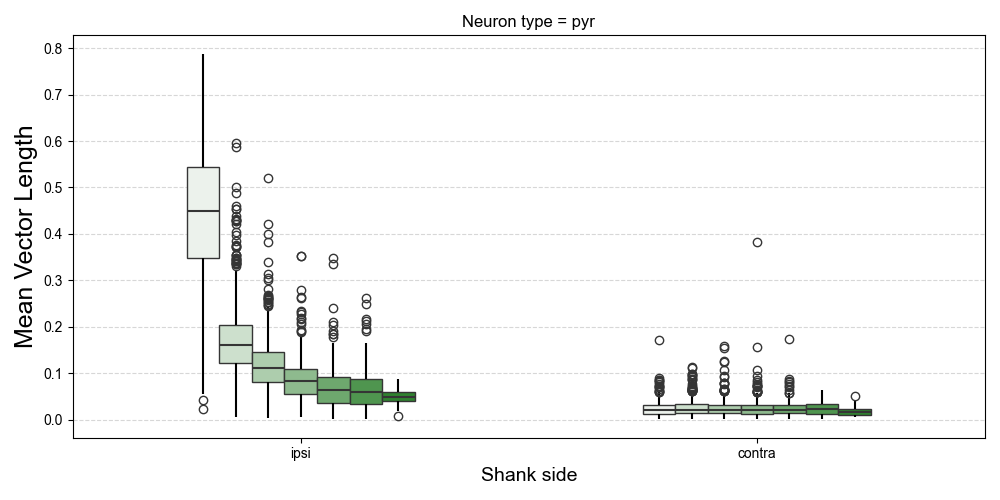

/tmp/ipykernel_12418/2900209645.py:12: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  box = sns.boxplot(data=df_sliced, x='neuron_to_ripple_side', hue="shank_distance", y='mean_vector_length',


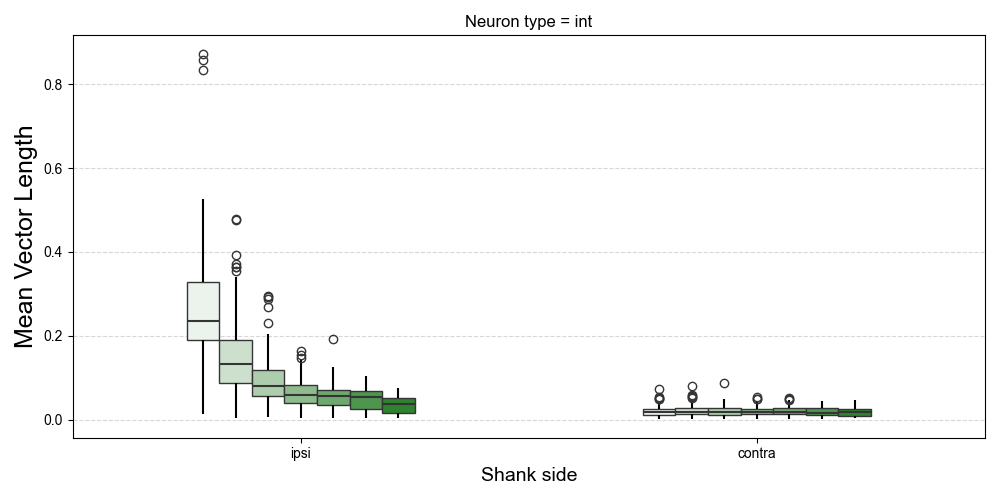

In [8]:
for neuron_type in ['pyr','int']:
    df_sliced = df[df['neuron_type']==neuron_type]
    
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42
    
    # plt.close('all')
    plt.figure(figsize=(10,5))
    
    my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}
    
    box = sns.boxplot(data=df_sliced, x='neuron_to_ripple_side', hue="shank_distance", y='mean_vector_length',
                order=["ipsi", "contra"], showfliers=True, showcaps=False,
                whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
                medianprops=dict(linestyle='-', linewidth=1.5),
                width=0.5,palette=custom_palette)  # Using the custom color palette
    
    plt.ylabel('Mean Vector Length',fontsize=18)
    plt.xlabel('Shank side',fontsize=14)
    plt.grid(linestyle='--',alpha=0.5,axis='y')
    plt.legend([], [], frameon=False)
    plt.title('Neuron type = ' + neuron_type)
    # plt.ylim([0,1])
    
    # we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
    # plt.xticks([0,1],labels=['Left','Right'])
    plt.tight_layout()
    
    
    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_mean_vector_length_across_distance.svg'
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # hf.delete_clip_path(fig_name)



In [12]:
import statsmodels.api as sm

df_sliced = df[df['neuron_type']=='int']

# Define the formula for the mixed-effects model
formula = "mean_vector_length ~ C(neuron_to_ripple_side, Treatment(reference='ipsi')) * shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_sliced,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                                              Mixed Linear Model Regression Results
Model:                                   MixedLM                      Dependent Variable:                      mean_vector_length
No. Observations:                        1348                         Method:                                  REML              
No. Groups:                              4                            Scale:                                   0.0040            
Min. group size:                         194                          Log-Likelihood:                          1781.1223         
Max. group size:                         605                          Converged:                               No                
Mean group size:                         337.0                                                                                   
---------------------------------------------------------------------------------------------------------------------------------
      

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 9.076496
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_

In [13]:
result.pvalues

Intercept                                                                                 1.421153e-70
C(neuron_to_ripple_side, Treatment(reference='ipsi'))[T.contra]                          2.251035e-244
shanks_distance_units                                                                    2.544110e-157
C(neuron_to_ripple_side, Treatment(reference='ipsi'))[T.contra]:shanks_distance_units     1.505615e-81
rat Var                                                                                            NaN
session Var                                                                               1.674627e-01
dtype: float64

In [14]:
import statsmodels.api as sm
data_sliced = df[(df['neuron_type']=='int') & (df['neuron_to_ripple_side'] == 'ipsi')]

# Define the formula for the mixed-effects model
formula = "mean_vector_length ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_sliced,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: mean_vector_length
No. Observations:  686     Method:             REML              
No. Groups:        4       Scale:              0.0076            
Min. group size:   117     Log-Likelihood:     686.9348          
Max. group size:   293     Converged:          Yes               
Mean group size:   171.5                                         
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              0.213    0.009  23.525 0.000  0.195  0.231
shanks_distance_units -0.044    0.002 -19.332 0.000 -0.048 -0.039
rat Var                0.000    0.004                            
session Var            0.000    0.003                            

shanks_distance_units coefficient = -0.04377521681307487
shanks_distance_units in % of in

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [15]:
result.pvalues 

Intercept                2.248302e-122
shanks_distance_units     2.896753e-83
rat Var                   9.805767e-01
session Var               2.010017e-01
dtype: float64

In [16]:
import statsmodels.api as sm
data_sliced = df[(df['neuron_type']=='int') & (df['neuron_to_ripple_side'] == 'contra')]

# Define the formula for the mixed-effects model
formula = "mean_vector_length ~ shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=data_sliced,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())
print('shanks_distance_units coefficient = ' + str(result.fe_params['shanks_distance_units']))
print('shanks_distance_units in % of intercept = ' + str(100*(result.fe_params['shanks_distance_units']/result.fe_params['Intercept'])) + ' %')


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_vector_length
No. Observations: 662     Method:             REML              
No. Groups:       4       Scale:              0.0001            
Min. group size:  77      Log-Likelihood:     1963.7205         
Max. group size:  312     Converged:          No                
Mean group size:  165.5                                         
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.022    0.004  6.388 0.000  0.016  0.029
shanks_distance_units -0.000    0.000 -0.978 0.328 -0.001  0.000
rat Var                0.000                                    
session Var            0.000                                    

shanks_distance_units coefficient = -0.0003004363802029119
shanks_distance_units in % of intercept = -1

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 8.178697
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_

In [17]:
result.fe_params

Intercept                0.022417
shanks_distance_units   -0.000300
dtype: float64

In [49]:
result.pvalues 

Intercept                6.642234e-231
shanks_distance_units     3.796883e-01
rat Var                   9.999945e-01
session Var               3.117443e-01
dtype: float64

/tmp/ipykernel_12418/1998758379.py:12: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  box = sns.boxplot(data=df_sliced, x='neuron_to_ripple_side', hue="shank_distance", y='firing_rate_difference',


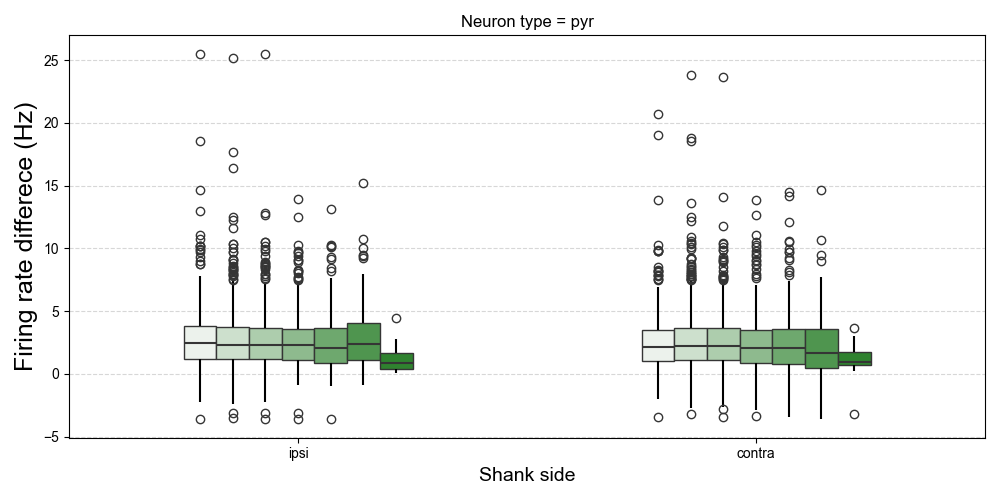

/tmp/ipykernel_12418/1998758379.py:12: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  box = sns.boxplot(data=df_sliced, x='neuron_to_ripple_side', hue="shank_distance", y='firing_rate_difference',


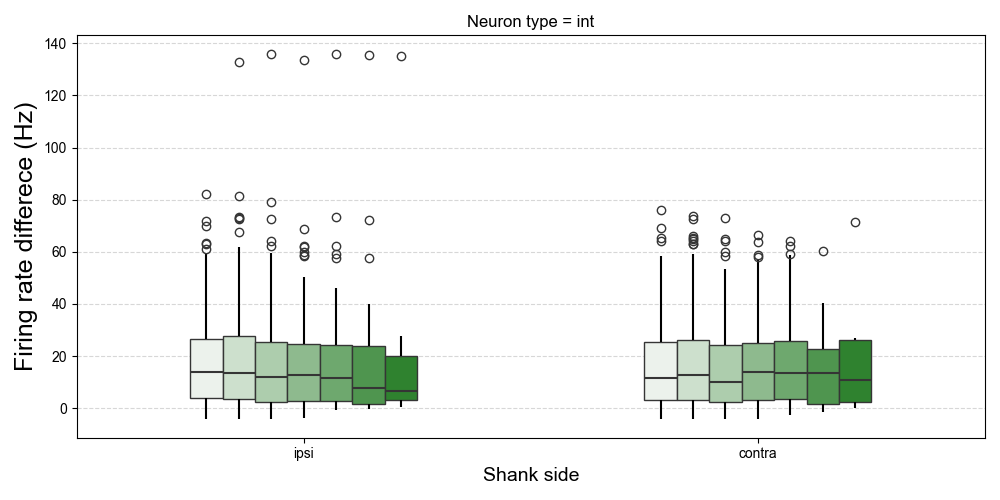

In [18]:
for neuron_type in ['pyr','int']:
    
    df_sliced = df[df['neuron_type']==neuron_type]
    
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42
    
    # plt.close('all')
    plt.figure(figsize=(10,5))
    
    
    box = sns.boxplot(data=df_sliced, x='neuron_to_ripple_side', hue="shank_distance", y='firing_rate_difference',
                order=["ipsi", "contra"], showfliers=True, showcaps=False,
                whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
                medianprops=dict(linestyle='-', linewidth=1.5),
                width=0.5,palette=custom_palette)  # Using the custom color palette
    
    plt.ylabel('Firing rate differece (Hz)',fontsize=18)
    plt.xlabel('Shank side',fontsize=14)
    plt.grid(linestyle='--',alpha=0.5,axis='y')
    plt.legend([], [], frameon=False)
    # plt.ylim([0,1])
    plt.title('Neuron type = ' + neuron_type)
    
    # we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
    # plt.xticks([0,1],labels=['Left','Right'])
    plt.tight_layout()
    
    
    os.chdir(figures_path + '/figure_7/')
    fig_name = neuron_type + '_firing_rate_difference_across_distance.svg'
    # plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
    plt.show()
    # hf.delete_clip_path(fig_name)



In [22]:
import statsmodels.api as sm

df_sliced = df[df['neuron_type']=='pyr']

# Define the formula for the mixed-effects model
formula = "firing_rate_difference ~ C(neuron_to_ripple_side, Treatment(reference='ipsi')) * shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_sliced,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                                             Mixed Linear Model Regression Results
Model:                                MixedLM                     Dependent Variable:                     firing_rate_difference
No. Observations:                     5953                        Method:                                 REML                  
No. Groups:                           4                           Scale:                                  4.9793                
Min. group size:                      480                         Log-Likelihood:                         -13247.8714           
Max. group size:                      2332                        Converged:                              Yes                   
Mean group size:                      1488.2                                                                                    
--------------------------------------------------------------------------------------------------------------------------------
              

In [20]:
import statsmodels.api as sm

df_sliced = df[df['neuron_type']=='int']

# Define the formula for the mixed-effects model
formula = "firing_rate_difference ~ C(neuron_to_ripple_side, Treatment(reference='ipsi')) * shanks_distance_units"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_sliced,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                                             Mixed Linear Model Regression Results
Model:                                MixedLM                     Dependent Variable:                     firing_rate_difference
No. Observations:                     1348                        Method:                                 REML                  
No. Groups:                           4                           Scale:                                  348.7320              
Min. group size:                      194                         Log-Likelihood:                         -5862.3417            
Max. group size:                      605                         Converged:                              No                    
Mean group size:                      337.0                                                                                     
--------------------------------------------------------------------------------------------------------------------------------
              

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 0.798119
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [7]:

os.chdir(tables_path + '/figure_7/')

df = pd.read_csv('Figure_Ripple_Spiking_Coupling.csv')
df = df[df['shank_distance'] != 1400]
df
# df['shank_distance'] = df['shank_distance'].astype('category')
# Assuming df is your DataFrame and 'shank_distance' is a categorical column
# df['shank_distance'] = df['shank_distance'].cat.remove_categories(1400)


,rat,session,shank_side,shank_distance,neuron_shank,neuron_ID,neuron_type,neuron_to_ripple_side,ripple_shank,mean_vector_length_ripple_epochs,mean_phase_ripple_epochs,number_of_spikes_ripple_epochs,mean_vector_length,mean_vector_length_unbiased,mean_vector_length_zscored,mean_vector_length_pval,firing_rate_outside_ripples,firing_rate_inside_ripples,firing_rate_difference,firing_rate_ratio
0,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_102,pyr,ipsi,0,0.329950,2.326562,384,0.342884,0.328201,45.021877,0.0,0.865156,4.516202,3.651046,5.220101
1,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_107,pyr,ipsi,0,0.238628,2.350893,35,0.204645,0.172389,10.479484,0.0,0.178380,0.411633,0.233253,2.307622
2,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_108,pyr,ipsi,0,0.366085,2.368665,260,0.371515,0.354449,39.074789,0.0,0.774117,3.057845,2.283728,3.950107
3,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_110,pyr,ipsi,0,0.496837,2.138610,146,0.491645,0.461112,28.039154,0.0,0.163301,1.717098,1.553796,10.514898
4,Ach,Achilles_10252013,left,0.0,0,Achilles_10252013_neuron_112,pyr,ipsi,0,0.296566,2.214096,240,0.304663,0.279765,21.003133,0.0,0.251780,2.822626,2.570846,11.210683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7302,Gat,Gatsby_08282013,right,0.0,6,Gatsby_08282013_neuron_726,int,contra,14,0.052450,2.362295,2550,0.048193,0.042410,12.893987,0.0,7.475653,23.998103,16.522450,3.210168
7303,Gat,Gatsby_08282013,right,200.0,13,Gatsby_08282013_neuron_1402,int,ipsi,14,0.164941,-1.190742,4048,0.030138,0.025449,10.284398,0.0,10.927826,38.095812,27.167986,3.486129
7304,Gat,Gatsby_08282013,right,200.0,13,Gatsby_08282013_neuron_1403,int,ipsi,14,0.546243,-2.325416,6368,0.220510,0.215691,83.662716,0.0,10.525392,59.929380,49.403988,5.693791
7305,Gat,Gatsby_08282013,right,200.0,13,Gatsby_08282013_neuron_1404,int,ipsi,14,0.175031,2.367619,10356,0.155853,0.151845,67.254974,0.0,24.894514,97.460530,72.566016,3.914940


In [9]:
np.unique(df.neuron_ID & df.pyr).shape

AttributeError: 'DataFrame' object has no attribute 'pyr'

In [45]:
687*2

1374

In [10]:
np.unique(df.neuron_ID[df['neuron_type'] =='pyr']).shape

(559,)

In [50]:
559*2


1118

In [11]:
np.unique(df.neuron_ID[df['neuron_type'] =='int']).shape

(128,)

In [12]:

spiking_dict = dict()
spiking_dict['rat'] = []
spiking_dict['session'] = []
spiking_dict['neuron_id'] = []
spiking_dict['neuron_type'] = []
spiking_dict['side'] = []
spiking_dict['mean_vector_length_ripple_epochs'] = []
spiking_dict['mean_vector_length'] = []
spiking_dict['mean_vector_length_zscored'] = []
spiking_dict['mean_vector_length_unbiased'] = []
spiking_dict['mean_vector_length_pval'] = []
spiking_dict['firing_rate_difference'] = []
spiking_dict['firing_rate_ratio'] = []

shank_distance_mask = df['shank_distance'] >= 0
neuron_id_labels = np.unique(df['neuron_ID'])

for neuron_counter,neuron_id in enumerate(neuron_id_labels):
    neuron_id_mask = df['neuron_ID'] == neuron_id
    
    for side_label in ['ipsi','contra']:
        side_mask = df['neuron_to_ripple_side'] == side_label

        if np.sum(neuron_id_mask*shank_distance_mask*side_mask) > 0:
        
            df_sliced = df[neuron_id_mask*shank_distance_mask*side_mask]
    
            spiking_dict['rat'].append(np.unique(df_sliced['rat'])[0])
            spiking_dict['session'].append(np.unique(df_sliced['session'])[0])           
            spiking_dict['neuron_id'].append(neuron_counter)
            
            spiking_dict['side'].append(side_label)
            spiking_dict['neuron_type'].append(np.unique(df_sliced['neuron_type'])[0])
            spiking_dict['mean_vector_length_ripple_epochs'].append(np.nanmean(df_sliced['mean_vector_length_ripple_epochs']))
            spiking_dict['mean_vector_length'].append(np.nanmean(df_sliced['mean_vector_length']))
            spiking_dict['mean_vector_length_zscored'].append(np.nanmean(df_sliced['mean_vector_length_zscored']))
            spiking_dict['mean_vector_length_unbiased'].append(np.nanmean(df_sliced['mean_vector_length_unbiased']))
            spiking_dict['mean_vector_length_pval'].append(np.nanmean(df_sliced['mean_vector_length_pval']))
            spiking_dict['firing_rate_difference'].append(np.nanmean(df_sliced['firing_rate_difference']))
            spiking_dict['firing_rate_ratio'].append(np.nanmean(df_sliced['firing_rate_ratio']))

        else:
            df_sliced = df[neuron_id_mask]
    
            spiking_dict['rat'].append(np.unique(df_sliced['rat'])[0])
            spiking_dict['session'].append(np.unique(df_sliced['session'])[0])           
            spiking_dict['neuron_id'].append(neuron_counter)
            spiking_dict['side'].append(side_label)
            spiking_dict['neuron_type'].append(np.unique(df_sliced['neuron_type'])[0])
            
            spiking_dict['mean_vector_length_ripple_epochs'].append(np.nan)
            spiking_dict['mean_vector_length'].append(np.nan)
            spiking_dict['mean_vector_length_zscored'].append(np.nan)
            spiking_dict['mean_vector_length_unbiased'].append(np.nan)
            spiking_dict['mean_vector_length_pval'].append(np.nan)
            spiking_dict['firing_rate_difference'].append(np.nan)
            spiking_dict['firing_rate_ratio'].append(np.nan)
            
df_new = pd.DataFrame(spiking_dict)
df_new['session'] = pd.Categorical(df_new['session'])
df_new['rat'] = pd.Categorical(df_new['rat'])


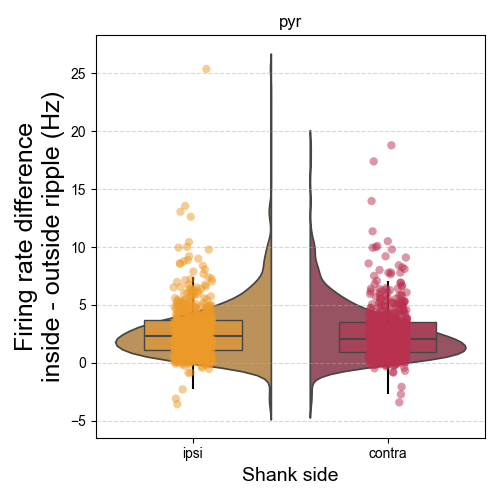

In [13]:

neuron_type = 'pyr'
df_sliced = df_new[df_new['neuron_type']==neuron_type]

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df_sliced, x="side",hue="side",y="firing_rate_difference", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=0.5)

box = sns.boxplot(data=df_sliced, x='side', hue="side", y='firing_rate_difference',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal)  # Using the custom color palette

sns.violinplot(data=df_sliced,x='side', hue="side",order=["ipsi", "contra"], y='firing_rate_difference',palette=my_pal,
               fill=True,inner = None,split=True, density_norm='width',saturation=0.5)

plt.ylabel('Firing rate difference\ninside - outside ripple (Hz)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.title(neuron_type)

# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
plt.xticks([0,1],labels=['ipsi','contra'])
plt.tight_layout()

os.chdir(figures_path + '/figure_7/')
fig_name = neuron_type + '_firing_rate_difference.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)


In [15]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "firing_rate_difference ~ C(side, Treatment(reference='ipsi'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_sliced,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


                          Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        firing_rate_difference
No. Observations:        1118           Method:                    REML                  
No. Groups:              4              Scale:                     5.0867                
Min. group size:         96             Log-Likelihood:            -2506.8470            
Max. group size:         424            Converged:                 Yes                   
Mean group size:         279.5                                                           
-----------------------------------------------------------------------------------------
                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                       2.528    0.340  7.436 0.000  1.862  3.194
C(side, Treatment(reference='ipsi'))

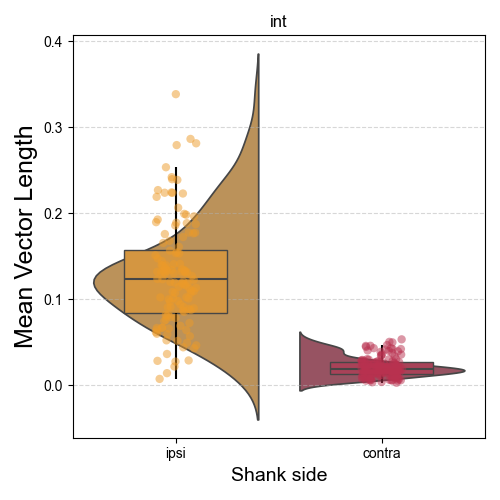

In [16]:

neuron_type = 'int'
df_sliced = df_new[df_new['neuron_type']==neuron_type]


plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

sns.stripplot(data=df_sliced, x="side",hue="side",y="mean_vector_length", order=["ipsi", "contra"],
              palette=my_pal,size=6,legend=False,alpha=0.5)

box = sns.boxplot(data=df_sliced, x='side', hue="side", y='mean_vector_length',
            order=["ipsi", "contra"], showfliers=False, showcaps=False,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5, palette=my_pal)  # Using the custom color palette

sns.violinplot(data=df_sliced,x='side', hue="side",order=["ipsi", "contra"], y='mean_vector_length',palette=my_pal,
               fill=True,inner = None,split=True, density_norm='width',saturation=0.5)

plt.ylabel('Mean Vector Length',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
plt.legend([], [], frameon=False)
plt.title(neuron_type)

# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
plt.xticks([0,1],labels=['ipsi','contra'])
plt.tight_layout()

os.chdir(figures_path + '/figure_7/')
# fig_name = neuron_type + '_mean_vector_length.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()

# hf.delete_clip_path(fig_name)


In [60]:
import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "mean_vector_length ~ C(side, Treatment(reference='ipsi'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_sliced,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                          Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         mean_vector_length
No. Observations:           256             Method:                     REML              
No. Groups:                 4               Scale:                      0.0019            
Min. group size:            40              Log-Likelihood:             425.3785          
Max. group size:            110             Converged:                  No                
Mean group size:            64.0                                                          
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       0.128    0.006  19.991 0.000  0.115  0.140
C(side, Treatment(referenc

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 7.772119
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_

In [61]:
result.pvalues

Intercept                                         6.632014e-89
C(side, Treatment(reference='ipsi'))[T.contra]    6.767334e-85
rat Var                                                    NaN
session Var                                       7.799454e-01
dtype: float64

In [44]:
two_groups_paired_baseline = dabest.load(data=df_sliced, x="side",y="mean_vector_length",idx=("ipsi", "contra"), paired="baseline", id_col="neuron_id")
# two_groups_paired_baseline.hedges_g.plot(float_contrast=True)
two_groups_paired_baseline.hedges_g.statistical_tests


,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,ipsi,contra,559,559,Hedges' g,baseline,-3.31051,95,-3.558351,-2.9165,0.0,3.041915e-93,6.0,2.231170e-239,58.261359


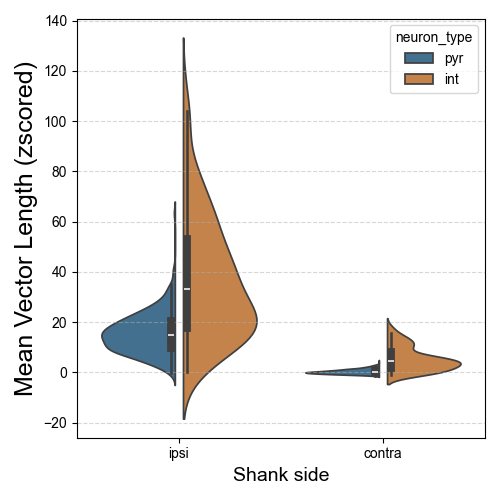

In [17]:
#  fazer esta figura só pra shank distance de zero

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.close('all')
plt.figure(figsize=(5,5))

sns.violinplot(data=df_new,x='side', hue="neuron_type",order=["ipsi", "contra"], y='mean_vector_length_zscored',
               fill=True,inner ='box' ,split=True, density_norm='width',saturation=0.5,gap=.1)

plt.ylabel('Mean Vector Length (zscored)',fontsize=18)
plt.xlabel('Shank side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
plt.xticks([0,1],labels=['ipsi','contra'])
plt.tight_layout()

os.chdir(figures_path + '/figure_7/')
fig_name =  'pooled_neurons_mean_vector_length_zscored.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fig_name)



In [18]:

import statsmodels.api as sm

# Define the formula for the mixed-effects model
formula = "mean_vector_length_zscored ~ C(side, Treatment(reference='ipsi'))*C(neuron_type,Treatment(reference='pyr'))"
re_formula = "1"
vc_formula = {"session": "0 + session"}
# Fit the mixed-effects model
model = sm.MixedLM.from_formula(formula, re_formula=re_formula, vc_formula=vc_formula, data=df_new,groups='rat')
result = model.fit()

# Print summary of the model
print(result.summary())


/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                                                     Mixed Linear Model Regression Results
Model:                                     MixedLM                        Dependent Variable:                        mean_vector_length_zscored
No. Observations:                          1374                           Method:                                    REML                      
No. Groups:                                4                              Scale:                                     85.1127                   
Min. group size:                           136                            Log-Likelihood:                            -5007.3027                
Max. group size:                           494                            Converged:                                 No                        
Mean group size:                           343.5                                                                                               
---------------------------------------------

/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 20.280123
  warnings.warn(msg, ConvergenceWarning)
/home/apolo/.pyenv/versions/ripple_sync/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [19]:
pyr_mask = df_new['neuron_type'] == 'pyr'
int_mask = df_new['neuron_type'] == 'int'

ipsi_mask = df_new['side'] == 'ipsi'
contra_mask = df_new['side'] == 'contra'


In [20]:

t_val,pval_pyr_ipsi_pyr_contra = stats.ttest_rel(df_new[pyr_mask*ipsi_mask]['mean_vector_length_zscored'],df_new[pyr_mask*contra_mask]['mean_vector_length_zscored'])
print('pyr ipsi vs pyr contra')
print(pval_pyr_ipsi_pyr_contra)
print(t_val)
print('\n')

t_val,pval_int_ipsi_int_contra = stats.ttest_rel(df_new[int_mask*ipsi_mask]['mean_vector_length_zscored'],df_new[int_mask*contra_mask]['mean_vector_length_zscored'])
print('int ipsi vs int contra')
print(pval_int_ipsi_int_contra)
print(t_val)
print('\n')

t_val,pval_pyr_ipsi_int_ipsi = stats.ttest_ind(df_new[pyr_mask*ipsi_mask]['mean_vector_length_zscored'],df_new[int_mask*ipsi_mask]['mean_vector_length_zscored'])
print('pyr ipsi vs int ipsi')
print(pval_pyr_ipsi_int_ipsi)
print(t_val)
print('\n')

t_val,pval_pyr_contra_int_contra = stats.ttest_ind(df_new[pyr_mask*contra_mask]['mean_vector_length_zscored'],df_new[int_mask*contra_mask]['mean_vector_length_zscored'])
print('pyr contra vs int contra')
print(pval_pyr_contra_int_contra)
print(t_val)
print('\n')


pyr ipsi vs pyr contra
2.1085854820730566e-188
45.138689439644395


int ipsi vs int contra
2.3534296012715303e-32
16.052656001915206


pyr ipsi vs int ipsi
1.0023216121118213e-54
-17.074376774022262


pyr contra vs int contra
2.065681919874347e-85
-22.68583505403977




In [21]:
int_ipsi_bool = (df_new['neuron_type']=='int') & (df_new['side']=='ipsi')
int_contra_bool = (df_new['neuron_type']=='int') & (df_new['side']=='contra')

int_ipsi = np.zeros(np.sum(int_ipsi_bool))
sign_mask = df_new['mean_vector_length_pval'][int_ipsi_bool] < 0.05
int_ipsi[sign_mask] = 1

int_contra = np.zeros(np.sum(int_contra_bool))
sign_mask = df_new['mean_vector_length_pval'][int_contra_bool] < 0.05
int_contra[sign_mask] = 1


pyr_ipsi_bool = (df_new['neuron_type']=='pyr') & (df_new['side']=='ipsi')
pyr_contra_bool = (df_new['neuron_type']=='pyr') & (df_new['side']=='contra')

pyr_ipsi = np.zeros(np.sum(pyr_ipsi_bool))
sign_mask = df_new['mean_vector_length_pval'][pyr_ipsi_bool] < 0.05
pyr_ipsi[sign_mask] = 1

pyr_contra = np.zeros(np.sum(pyr_contra_bool))
sign_mask = df_new['mean_vector_length_pval'][pyr_contra_bool] < 0.05
pyr_contra[sign_mask] = 1



In [87]:
pyr_ipsi.shape[0]

559

In [22]:
np.sum(pyr_ipsi)/pyr_ipsi.shape[0]

0.851520572450805

In [23]:
np.sum(pyr_contra)/pyr_contra.shape[0]

0.046511627906976744

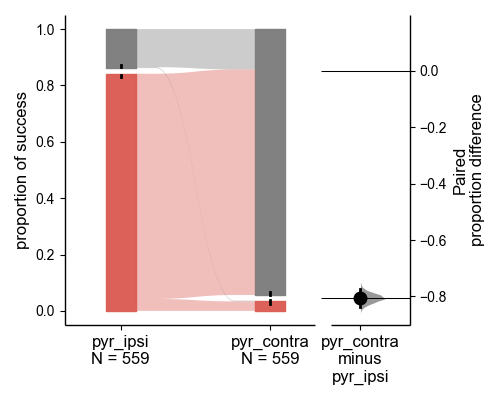

In [24]:

neurons_id = np.arange(0,pyr_ipsi.shape[0])

df_prop = pd.DataFrame({'neurons_id':neurons_id,'pyr_ipsi':pyr_ipsi,'pyr_contra':pyr_contra})
df_prop

two_groups_baseline = dabest.load(df_prop, idx=("pyr_ipsi", "pyr_contra"), 
                                  proportional=True, paired="baseline", id_col="neurons_id")
    
two_groups_baseline.mean_diff.plot();

os.chdir(figures_path + '/figure_7/')
fig_name =  'pyr_proportion_significant_ipsi_vs_contra.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
# hf.delete_clip_path(fig_name)


In [73]:

two_groups_baseline.mean_diff

DABEST v2024.03.29
                  
Good afternoon!
The current time is Sat Sep 28 17:36:10 2024.

The paired mean difference for repeated measures against baseline 
between pyr_ipsi and pyr_contra is -0.805 [95%CI -0.839, -0.773].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`

In [77]:
int_contra

array([1., 0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1.,
       0., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
       0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.,
       1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0.,
       1., 1., 0., 0., 1., 1., 1., 1., 1.])

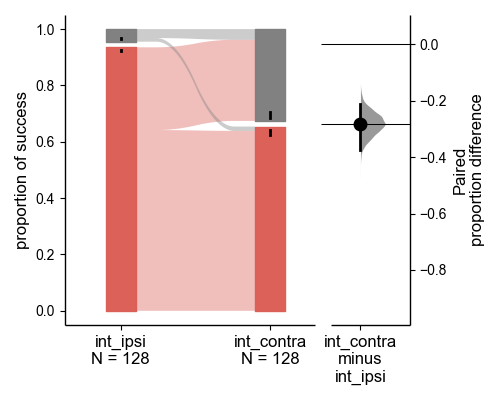

In [82]:

neurons_id = np.arange(0,int_ipsi.shape[0])

df_prop = pd.DataFrame({'neurons_id':neurons_id,'int_ipsi':int_ipsi,'int_contra':int_contra})
df_prop

two_groups_baseline = dabest.load(df_prop, idx=("int_ipsi", "int_contra"), 
                                  proportional=True, paired="baseline", id_col="neurons_id")
    
two_groups_baseline.mean_diff.plot();

os.chdir(figures_path + '/figure_7/')
fig_name =  'int_proportion_significant_ipsi_vs_contra.svg'
# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
# hf.delete_clip_path(fig_name)


In [83]:
two_groups_baseline.mean_diff

DABEST v2024.03.29
                  
Good afternoon!
The current time is Sat Sep 28 17:39:19 2024.

The paired mean difference for repeated measures against baseline 
between int_ipsi and int_contra is -0.281 [95%CI -0.375, -0.211].
The p-value of the two-sided permutation t-test is 0.0, calculated for legacy purposes only. 

5000 bootstrap samples were taken; the confidence interval is bias-corrected and accelerated.
Any p-value reported is the probability of observing theeffect size (or greater),
assuming the null hypothesis of zero difference is true.
For each p-value, 5000 reshuffles of the control and test labels were performed.

To get the results of all valid statistical tests, use `.mean_diff.statistical_tests`

In [86]:
int_ipsi.shape[0]

128

In [84]:
np.sum(int_ipsi)/int_ipsi.shape[0]

0.9453125

In [85]:
np.sum(int_contra)/int_contra.shape[0]


0.6640625